# 7. Missing Data & Imputation Analysis – Zein 

Questions:  

What happens if you drop missing cost values? 

What happens if you impute them?

In [ ]:
#Import Libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import pandas as pd
import numpy as np
import plotly.express as px

In [ ]:
#Import the dataset 
df = pd.read_csv("failures_data.csv")

In [3]:
# Check the first rows of dataset 
df.head()

,BANKNO,BIDCITY,BIDNAME,BIDSTATE,BRDATE,BSTATUS,CERT,CHCLASS,CHCLASS1,CITY,...,PTRDATE,QBFASSET,QBFDEP,RESDATE,RESTYPE,RESTYPE1,SAVR,TERMI,UNINSDEP,URL
0,NaN,0,0,0,NaN,NaN,NaN,NM,NM,EAST PEORIA,...,0,374.0,238.0,NaN,FAILURE,PO,FDIC,NaN,NaN,NaN
1,NaN,0,0,0,NaN,NaN,NaN,NM,NM,GRANTWOOD,...,0,2305.0,590.0,NaN,FAILURE,PO,FDIC,NaN,NaN,NaN
2,NaN,0,0,0,NaN,NaN,NaN,NM,NM,CUMMINGS,...,0,NaN,30.0,NaN,FAILURE,P&A,FDIC,NaN,NaN,NaN
3,NaN,LINCOLN,UNION BANK&TRUST CO,NE,NaN,I,13797.0,NM,NM,TAYLOR,...,0,14542.0,13360.0,5/31/1985,FAILURE,PA,FDIC,T,NaN,na
4,NaN,0,0,0,NaN,I,18388.0,NM,NM,FAIRFIELD,...,0,6795.0,6034.0,5/31/1985,FAILURE,PO,FDIC,T,NaN,na


In [4]:
# Check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4114 entries, 0 to 4113
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BANKNO              747 non-null    float64
 1   BIDCITY             4114 non-null   object 
 2   BIDNAME             4114 non-null   object 
 3   BIDSTATE            3873 non-null   object 
 4   BRDATE              930 non-null    object 
 5   BSTATUS             2903 non-null   object 
 6   CERT                3626 non-null   float64
 7   CHCLASS             4114 non-null   object 
 8   CHCLASS1            4114 non-null   object 
 9   CITY                4114 non-null   object 
 10  CITYST              4114 non-null   object 
 11  CLOSCD              2656 non-null   object 
 12  COMMENTS            75 non-null     object 
 13  COST                3476 non-null   float64
 14  COSTMOSTRECENTASOF  3551 non-null   object 
 15  FAILDATE            4114 non-null   object 
 16  FAILYR

In [5]:
# get the columns names 
df.columns

Index(['BANKNO', 'BIDCITY', 'BIDNAME', 'BIDSTATE', 'BRDATE', 'BSTATUS', 'CERT',
       'CHCLASS', 'CHCLASS1', 'CITY', 'CITYST', 'CLOSCD', 'COMMENTS', 'COST',
       'COSTMOSTRECENTASOF', 'FAILDATE', 'FAILYR', 'FIN', 'FSL_PROG', 'FUND',
       'ID', 'NAME', 'PSTALP', 'PTRDATE', 'QBFASSET', 'QBFDEP', 'RESDATE',
       'RESTYPE', 'RESTYPE1', 'SAVR', 'TERMI', 'UNINSDEP', 'URL'],
      dtype='object')

In [6]:
# Check the dataset dimension
df.shape 

(4114, 33)

In [7]:
# Statistical summary of dataset 
df.describe()

,BANKNO,CERT,COST,FAILYR,FIN,FUND,ID,QBFASSET,QBFDEP,UNINSDEP
count,747.000000,3626.000000,3.476000e+03,4114.000000,4114.000000,4114.000000,4114.000000,3.960000e+03,4.112000e+03,167.000000
mean,8339.172691,24519.545229,8.463684e+04,1985.556636,4184.461595,2.010452,2057.500000,1.366029e+06,7.526654e+05,4801.880240
std,349.638493,11666.221909,5.264909e+05,18.386663,3336.837640,1.384200,1187.753833,3.127343e+07,1.620112e+07,11897.867376
min,7701.000000,40.000000,-1.138100e+04,1934.000000,0.000000,1.000000,1.000000,1.400000e+01,0.000000e+00,1.000000
25%,7964.500000,18268.500000,3.151500e+03,1985.000000,1755.250000,1.000000,1029.250000,1.801125e+04,1.464375e+04,131.500000
50%,8396.000000,26354.500000,1.131500e+04,1988.000000,2969.500000,1.000000,2057.500000,5.563150e+04,4.958600e+04,633.000000
75%,8595.500000,30988.500000,4.290175e+04,1991.000000,7033.750000,3.000000,3085.750000,1.976018e+05,1.751820e+05,3677.000000
max,8925.000000,91189.000000,1.895962e+07,2026.000000,12894.000000,5.000000,4114.000000,1.471631e+09,9.546776e+08,95318.000000


In [8]:
# Get statistical summary of the COST column  
df["COST"].describe()

count    3.476000e+03
mean     8.463684e+04
std      5.264909e+05
min     -1.138100e+04
25%      3.151500e+03
50%      1.131500e+04
75%      4.290175e+04
max      1.895962e+07
Name: COST, dtype: float64

In [9]:
# Check total of missing values for COST
cost_missing_values =  df["COST"].isnull().sum()

print("Total Missing values in COST", df["COST"].isnull().sum())

Total Missing values in COST 638


In [10]:
# Percentage of missing COST values
missing_percent = (df["COST"].isnull().sum() / len(df)) * 100

print(f"Missing COST values: {missing_percent:.2f}%")

Missing COST values: 15.51%


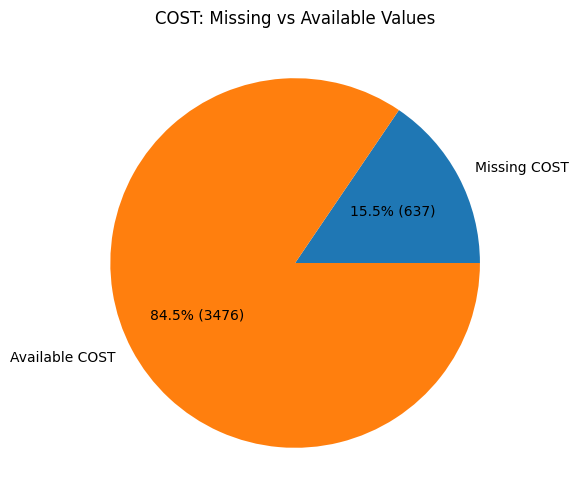

In [11]:
# Missing COST vs Available COST

# Calculate values
cost_missing = df["COST"].isnull().sum()
total = len(df)
cost_not_missing = total - cost_missing

# Data for pie chart
labels = ["Missing COST", "Available COST"]
sizes = [cost_missing, cost_not_missing]

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct=lambda p: f"{p:.1f}% ({int(p*sum(sizes)/100)})"
)
plt.title("COST: Missing vs Available Values")
plt.show()

### Create Decade Column

In [12]:
# Create decade column
df["DECADE"] = (df["FAILYR"] // 10) * 10

# Check result
print(df[["FAILYR", "DECADE"]].head(10))

   FAILYR  DECADE
0    1934    1930
1    1935    1930
2    1936    1930
3    1985    1980
4    1985    1980
5    1985    1980
6    1985    1980
7    1985    1980
8    1985    1980
9    1985    1980


### Missingness by Decade

In [13]:
# Count missing COST values by decade
# missing_by_decade = (
#     df.groupby("DECADE")["COST"]
#     .apply(lambda x: x.isnull().mean() * 100)
#     .reset_index(name="Missing_Percent")
# )

missing_by_decade = df.groupby("DECADE")["COST"].agg(
    Total_Missing=lambda x: x.isnull().sum(),
    Missing_Percent=lambda x: x.isnull().mean() * 100
).reset_index()


print(missing_by_decade)

   DECADE  Total_Missing  Missing_Percent
0    1930            312       100.000000
1    1940             99       100.000000
2    1950             28       100.000000
3    1960             44       100.000000
4    1970             79       100.000000
5    1980             61         2.996071
6    1990              1         0.108108
7    2000             13         6.190476
8    2010              0         0.000000
9    2020              1         7.142857


### Visualization — Missingness by Decade

C:\Users\Zein\AppData\Local\Temp\ipykernel_24396\288220027.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


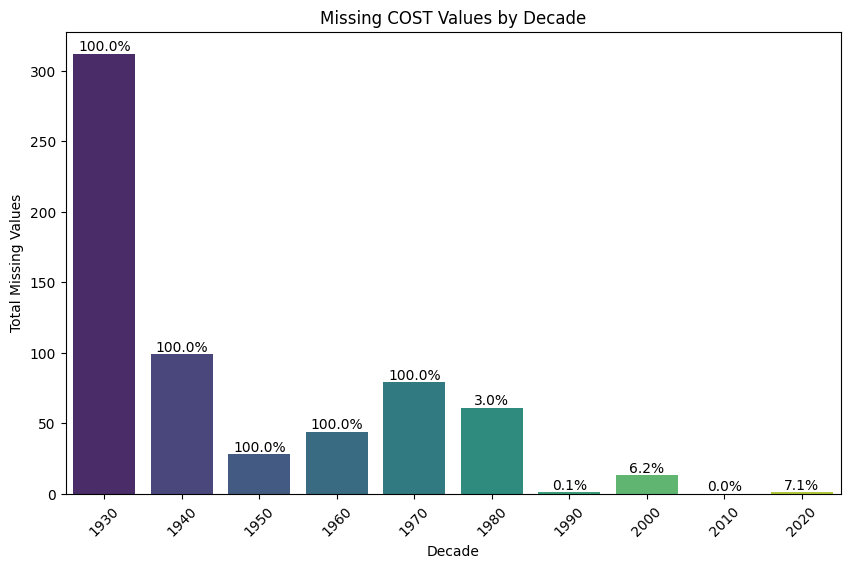

In [14]:
plt.figure(figsize=(10,6))

# Different colors per bar
colors = sns.color_palette("viridis", len(missing_by_decade))

ax = sns.barplot(
    data=missing_by_decade,
    x="DECADE",
    y="Total_Missing",
    palette=colors
)

plt.title("Missing COST Values by Decade")
plt.xlabel("Decade")
plt.ylabel("Total Missing Values")

# Add % labels on top of bars
for i, row in missing_by_decade.iterrows():
    ax.text(
        i,
        row["Total_Missing"],
        f'{row["Missing_Percent"]:.1f}%',
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=45)
plt.show()

### Drop Missing COST Values

In [15]:
# Dataset after dropping missing COST values
df_drop = df.dropna(subset=["COST"])

print("Original Shape:", df.shape)
print("After Dropping Missing COST:", df_drop.shape)

Original Shape: (4114, 34)
After Dropping Missing COST: (3476, 34)


In [16]:
# Original decade counts
original_counts = df["DECADE"].value_counts().sort_index()

# After dropping missing COST
drop_counts = df_drop["DECADE"].value_counts().sort_index()

comparison = pd.DataFrame({
    "Original": original_counts,
    "After_Drop": drop_counts
})

# Fill NaN with 0 and convert to int
comparison = comparison.fillna(0).astype(int)

print(comparison)

        Original  After_Drop
DECADE                      
1930         312           0
1940          99           0
1950          28           0
1960          44           0
1970          79           0
1980        2036        1975
1990         925         924
2000         210         197
2010         367         367
2020          14          13


### Mean and Median Imputation

In [17]:
# Create copies
df_mean = df.copy()
df_median = df.copy()

# Mean imputation
mean_value = df["COST"].mean()
df_mean["COST"] = df_mean["COST"].fillna(mean_value)

# Median imputation
median_value = df["COST"].median()
df_median["COST"] = df_median["COST"].fillna(median_value)

print("Mean:", mean_value)
print("Median:", median_value)

Mean: 84636.83573072497
Median: 11315.0


### Histogram Comparison

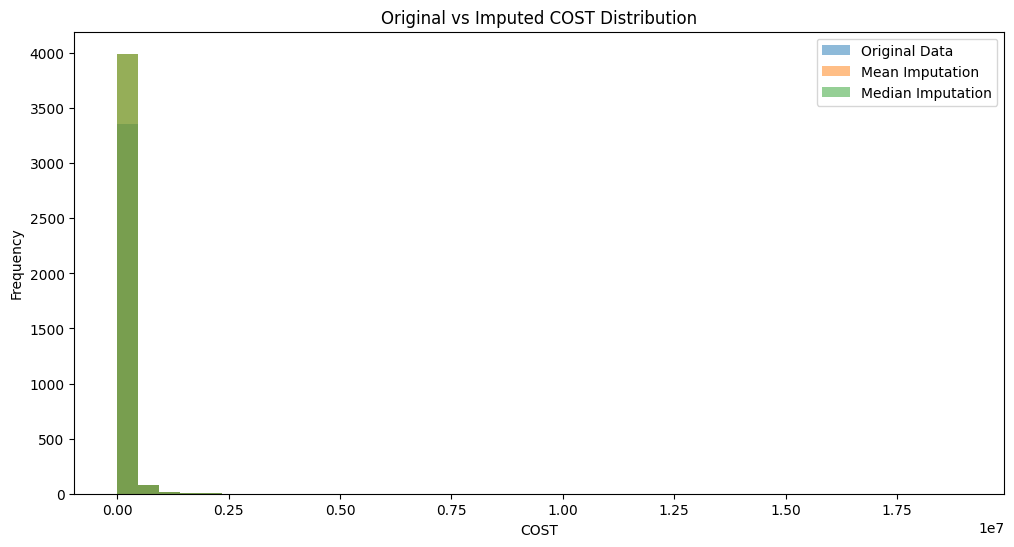

In [18]:
plt.figure(figsize=(12,6))

# Original data
plt.hist(
    df["COST"].dropna(),
    bins=40,
    alpha=0.5,
    label="Original Data"
)

# Mean imputation
plt.hist(
    df_mean["COST"],
    bins=40,
    alpha=0.5,
    label="Mean Imputation"
)

# Median imputation
plt.hist(
    df_median["COST"],
    bins=40,
    alpha=0.5,
    label="Median Imputation"
)

# Titles and labels
plt.title("Original vs Imputed COST Distribution")
plt.xlabel("COST")
plt.ylabel("Frequency")

# Legend
plt.legend()

plt.show()

In [19]:
# Create comparison dataframe
comparison_stats = pd.DataFrame({
    "Dataset": ["Original", "Mean Imputed", "Median Imputed"],
    "Mean_COST": [
        df["COST"].mean(),
        df_mean["COST"].mean(),
        df_median["COST"].mean()
    ],
    "Median_COST": [
        df["COST"].median(),
        df_mean["COST"].median(),
        df_median["COST"].median()
    ]
})

print(comparison_stats)

          Dataset     Mean_COST  Median_COST
0        Original  84636.835731      11315.0
1    Mean Imputed  84636.835731      17801.0
2  Median Imputed  73266.069762      11315.0


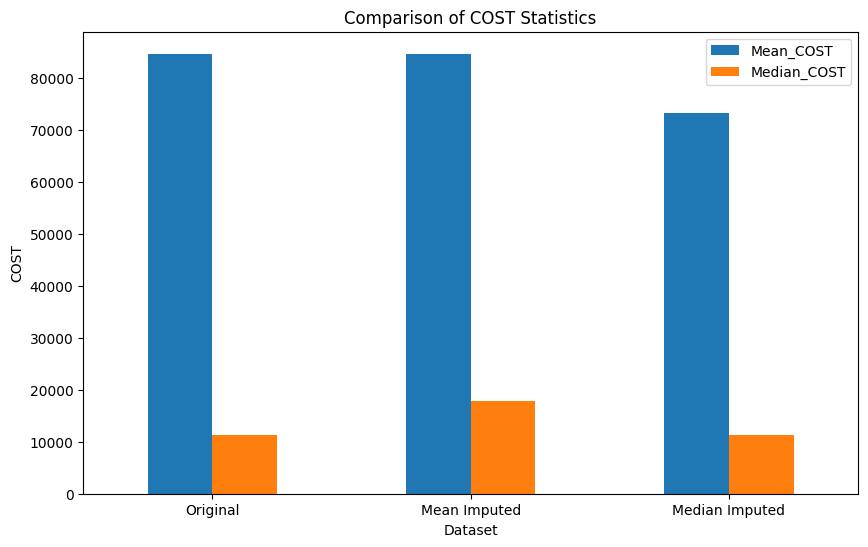

In [20]:
comparison_stats.plot(
    x="Dataset",
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of COST Statistics")
plt.ylabel("COST")

plt.xticks(rotation=0)

plt.show()

In [21]:
# Missingness Pattern
print(missing_by_decade)

   DECADE  Total_Missing  Missing_Percent
0    1930            312       100.000000
1    1940             99       100.000000
2    1950             28       100.000000
3    1960             44       100.000000
4    1970             79       100.000000
5    1980             61         2.996071
6    1990              1         0.108108
7    2000             13         6.190476
8    2010              0         0.000000
9    2020              1         7.142857


In [22]:
# Bias After Dropping Rows
print(comparison)

        Original  After_Drop
DECADE                      
1930         312           0
1940          99           0
1950          28           0
1960          44           0
1970          79           0
1980        2036        1975
1990         925         924
2000         210         197
2010         367         367
2020          14          13


In [23]:
# Imputation Effect
print(df["COST"].describe())
print("----------------------")
print(df_mean["COST"].describe())
print("----------------------")
print(df_median["COST"].describe())

count    3.476000e+03
mean     8.463684e+04
std      5.264909e+05
min     -1.138100e+04
25%      3.151500e+03
50%      1.131500e+04
75%      4.290175e+04
max      1.895962e+07
Name: COST, dtype: float64
----------------------
count    4.114000e+03
mean     8.463684e+04
std      4.839371e+05
min     -1.138100e+04
25%      4.050250e+03
50%      1.780100e+04
75%      8.463684e+04
max      1.895962e+07
Name: COST, dtype: float64
----------------------
count    4.114000e+03
mean     7.326607e+04
std      4.846646e+05
min     -1.138100e+04
25%      4.050250e+03
50%      1.131500e+04
75%      3.242550e+04
max      1.895962e+07
Name: COST, dtype: float64


In [24]:
# Create decade column
df["DECADE"] = (df["FAILYR"] // 10) * 10

# Count original non-missing COST values
original_counts = (
    df.groupby("DECADE")["COST"]
    .apply(lambda x: x.notnull().sum())
)

# Count missing values (these are the imputed values)
missing_counts = (
    df.groupby("DECADE")["COST"]
    .apply(lambda x: x.isnull().sum())
)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    "Original_Data": original_counts,
    "Mean_Imputed": missing_counts,
    "Median_Imputed": missing_counts
}).reset_index()

print(comparison_df)

   DECADE  Original_Data  Mean_Imputed  Median_Imputed
0    1930              0           312             312
1    1940              0            99              99
2    1950              0            28              28
3    1960              0            44              44
4    1970              0            79              79
5    1980           1975            61              61
6    1990            924             1               1
7    2000            197            13              13
8    2010            367             0               0
9    2020             13             1               1


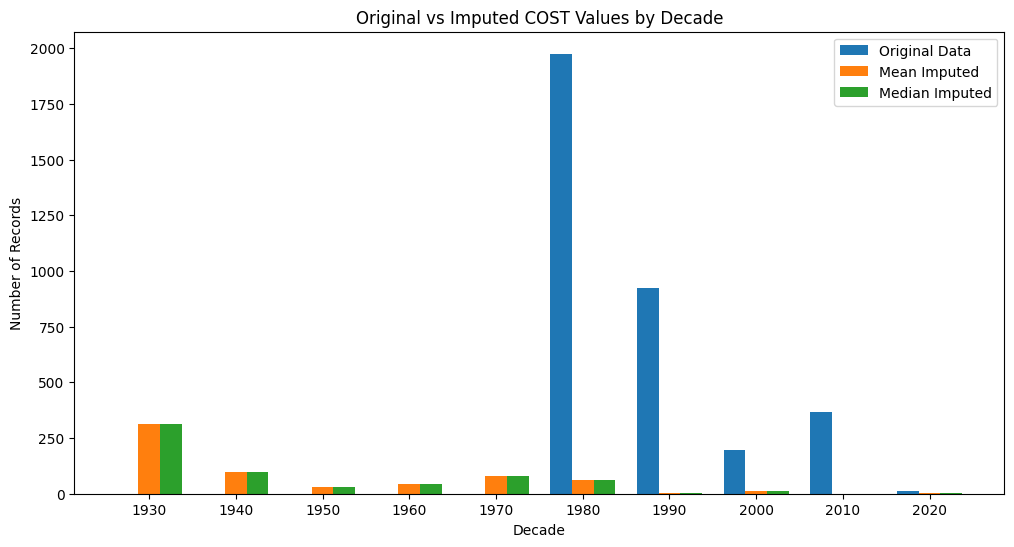

In [25]:
# Set figure size
plt.figure(figsize=(12,6))

# Width of bars
bar_width = 0.25

# X positions
x = np.arange(len(comparison_df["DECADE"]))

# Original data bars
plt.bar(
    x,
    comparison_df["Original_Data"],
    width=bar_width,
    label="Original Data"
)

# Mean imputed bars
plt.bar(
    x + bar_width,
    comparison_df["Mean_Imputed"],
    width=bar_width,
    label="Mean Imputed"
)

# Median imputed bars
plt.bar(
    x + (2 * bar_width),
    comparison_df["Median_Imputed"],
    width=bar_width,
    label="Median Imputed"
)

# Labels
plt.xlabel("Decade")
plt.ylabel("Number of Records")

# Title
plt.title("Original vs Imputed COST Values by Decade")

# X ticks
plt.xticks(
    x + bar_width,
    comparison_df["DECADE"]
)

# Legend
plt.legend()

plt.show()

### Automated Missing Value Imputation Dashboard

In [29]:
import sys
!{sys.executable} -m pip install dash

Defaulting to user installation because normal site-packages is not writeable
  Using cached dash-4.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached retrying-1.4.2-py3-none-any.whl.metadata (5.5 kB)
Using cached dash-4.1.0-py3-none-any.whl (7.2 MB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 5.1 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.9 MB 5.1 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/9.9 MB 5.3 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 5.4 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.9 MB 5.3 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.9 MB 5.4 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 5.4 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 5.4 MB/s eta 0:


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Zein\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [74]:
# =========================================================
# AUTOMATED IMPUTATION DASHBOARD (FINAL CLEAN VERSION)
# =========================================================

import dash
from dash import dcc, html
from dash.dependencies import Input, Output, State

import pandas as pd
import numpy as np
import plotly.express as px

import base64
import io

# =========================================================
# DEFAULT DATASET
# =========================================================

default_df = pd.read_csv("failures_data.csv")

# =========================================================
# APP
# =========================================================

app = dash.Dash(__name__)

# =========================================================
# SHINING BLUE STYLE
# =========================================================

TITLE_STYLE = {
    'textAlign': 'center',
    'color': '#1E90FF',
    'fontWeight': 'bold',
    'textShadow': '2px 2px 5px #87CEFA',
    'marginBottom': '30px'
}

SUBTITLE_STYLE = {
    'color': '#1E90FF',
    'fontWeight': 'bold'
}

# =========================================================
# LAYOUT (YOUR STYLE BLOCK INTEGRATED)
# =========================================================

app.layout = html.Div([

    # =====================================================
    # TITLE
    # =====================================================

    html.H1(
        "Automated Missing Value Imputation Dashboard",
        style=TITLE_STYLE
    ),

    # =====================================================
    # FIRST ROW INPUTS
    # =====================================================

    html.Div([

        # Upload
        html.Div([

            html.Label("Upload Dataset", style=SUBTITLE_STYLE),

            dcc.Upload(
                id='upload-data',
                children=html.Div([
                    "Drag & Drop or Click to Upload"
                ]),
                style={
                    'backgroundColor': '#f0f8ff',
                    'border': '2px dashed #1E90FF',
                    'padding': '10px',
                    'textAlign': 'center'
                }
            )

        ], style={'width': '45%'}),

        # File Type
        html.Div([

            html.Label("File Type", style=SUBTITLE_STYLE),

            dcc.Dropdown(
                id='file-type',
                options=[
                    {'label': 'CSV', 'value': 'csv'},
                    {'label': 'Excel', 'value': 'excel'}
                ],
                value='csv'
            )

        ], style={'width': '45%'})

    ], style={'display': 'flex', 'justifyContent': 'space-between'}),

    html.Br(),

    # =====================================================
    # SECOND ROW INPUTS (YOUR STYLE BLOCK)
    # =====================================================

    html.Div([

        # 1) Missing Value Column (NUMERIC ONLY)
        html.Div([

            html.Label(
                "Numeric Column with Missing Values",
                style=SUBTITLE_STYLE
            ),

            dcc.Dropdown(id='missing-column')

        ], style={'width': '30%'}),

        # 2) Column to Impute
        html.Div([

            html.Label(
                "Column to Impute Missing Values By",
                style=SUBTITLE_STYLE
            ),

            dcc.Dropdown(id='impute-column')

        ], style={'width': '30%'}),

        # 3) Time Dropdown
        html.Div([

            html.Label(
                "Time Grouping",
                style=SUBTITLE_STYLE
            ),

            dcc.Dropdown(
                id='time-group',
                options=[
                    {'label': 'Year', 'value': 'year'},
                    {'label': 'Decade', 'value': 'decade'},
                    {'label': 'Century', 'value': 'century'}
                ],
                value='decade',
                disabled=True
            )

        ], style={'width': '30%'})

    ], style={'display': 'flex', 'justifyContent': 'space-between'}),

    html.Br(),

    # =====================================================
    # KPI SECTION
    # =====================================================

    html.Div([

        html.Div([html.H3("Total"), html.H2(id='kpi-total')]),
        html.Div([html.H3("Missing"), html.H2(id='kpi-missing')]),
        html.Div([html.H3("Mean"), html.H2(id='kpi-mean')]),
        html.Div([html.H3("Median"), html.H2(id='kpi-median')]),
        html.Div([html.H3("Column Type"), html.H2(id='kpi-type')]),

    ], style={
        'display': 'flex',
        'justifyContent': 'space-between',
        'backgroundColor': '#D3D3D3',
        'padding': '15px',
        'borderRadius': '10px'
    }),

    html.Br(),

    # =====================================================
    # GRAPHS (PIE FIRST)
    # =====================================================

    dcc.Graph(id='pie-chart'),

    html.Div([
        dcc.Graph(id='missing-chart'),
        dcc.Graph(id='mean-median-chart')
    ], style={'display': 'flex'}),

    html.Div([
        dcc.Graph(id='comparison-chart'),
        dcc.Graph(id='box-plot')
    ], style={'display': 'flex'}),

    dcc.Graph(id='histogram-chart')

    # html.Div([
    #     dcc.Graph(id='histogram-chart'),
    #     dcc.Graph(id='decade-chart')
    # ], style={'display': 'flex'})

])

# =========================================================
# LOAD DATA
# =========================================================

def load_data(contents, filename):

    if contents is None:
        return default_df

    content_type, content_string = contents.split(',')
    decoded = base64.b64decode(content_string)

    try:
        if 'csv' in filename:
            return pd.read_csv(io.StringIO(decoded.decode('utf-8')))
        else:
            return pd.read_excel(io.BytesIO(decoded))
    except:
        return default_df

# =========================================================
# DROPDOWNS
# =========================================================

@app.callback(
    [
        Output('missing-column', 'options'),
        Output('missing-column', 'value'),

        Output('impute-column', 'options'),
        Output('impute-column', 'value'),

        Output('time-group', 'disabled')
    ],
    [
    Input('upload-data', 'contents'),
    Input('impute-column', 'value')  
    ],
    State('upload-data', 'filename')
)
def update_dropdowns(contents, impute_col, filename):

    df = load_data(contents, filename)

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    missing_cols = [c for c in numeric_cols if df[c].isnull().sum() > 0]
    all_cols = df.columns.tolist()

    time_cols = [c for c in df.columns if 'date' in c.lower() or 'year' in c.lower()]

    # detect selected column type
    if impute_col is None:
        time_disabled = True
    else:
        is_numeric = impute_col in numeric_cols
        is_date = impute_col in time_cols
        
        time_disabled = not (is_numeric or is_date)

    return (
        [{'label': c, 'value': c} for c in missing_cols],
        missing_cols[0] if missing_cols else None,

        [{'label': c, 'value': c} for c in all_cols],
        # impute_col if impute_col in all_cols else (all_cols[0] if all_cols else None),
        impute_col if impute_col in all_cols and impute_col is not None else None,


        time_disabled
    )

# =========================================================
# MAIN CALLBACK (ALL GRAPHS)
# =========================================================

@app.callback(
    [
        Output('kpi-total', 'children'),
        Output('kpi-missing', 'children'),
        Output('kpi-mean', 'children'),
        Output('kpi-median', 'children'),
        Output('kpi-type', 'children'),

        Output('pie-chart', 'figure'),
        Output('missing-chart', 'figure'),
        Output('mean-median-chart', 'figure'),
        Output('comparison-chart', 'figure'),
        Output('box-plot', 'figure'),
        Output('histogram-chart', 'figure')
    ],
    [
        Input('missing-column', 'value'),
        Input('impute-column', 'value'),
        Input('time-group', 'value')
    ],
    State('upload-data', 'contents')
)
def update_dashboard(missing_col, impute_col, time_group, contents):

    df = load_data(contents, None)

    if missing_col is None:
        # return "", "", "", "", {}, {}, {}, {}, {}, {}, {}
        return "", "", "", "", "", {}, {}, {}, {}, {}, {}

    # =====================================================
    # KPI
    # =====================================================

    total = len(df)
    missing = df[missing_col].isnull().sum()
    # missing = df.groupby("DECADE")[missing_col].apply(lambda x: x.isna().sum())
    mean_val = round(df[missing_col].mean(), 2)
    median_val = round(df[missing_col].median(), 2)
    # col_type = str(df[missing_col].dtype)
    dtype = str(df[missing_col].dtype)
    if "float" in dtype or "int" in dtype:
        col_type = "Numeric"

    elif "datetime" in dtype:
        col_type = "Date/Time"
        
    else:
        col_type = "Categorical"

    # =====================================================
    # PIE CHART (FIRST GRAPH)
    # =====================================================

    pie_df = pd.DataFrame({
        "Category": ["Missing", "Non-Missing"],
        "Count": [
            df[missing_col].isnull().sum(),
            df[missing_col].notnull().sum()
        ]
    })

    pie_chart = px.pie(
        pie_df,
        names="Category",
        values="Count",
        title="Missing vs Non-Missing Distribution",
        hole=0.4
    )

    # =====================================================
    # MISSING BAR
    # =====================================================

    missing_chart = px.bar(pie_df, x="Category", y="Count",
                           color="Category",
                           title="Missing vs Non-Missing")

    # =====================================================
    # MEAN vs MEDIAN
    # =====================================================

    mm_df = pd.DataFrame({
        "Stat": ["Mean", "Median"],
        "Value": [mean_val, median_val]
    })

    mean_median_chart = px.bar(mm_df,
                               x="Stat", y="Value", title="Mean vs Median",
                               color="Stat",
                               color_discrete_map={
                                   "Mean": "#1E90FF",     # bright blue
                                   "Median": "#FF8C00"    # orange
                                   },
                                text="Value")

    # =====================================================
    # GROUP COMPARISON BY DECADE (DYNAMIC COLUMN)
    # =====================================================

    year_col = impute_col  # selected dropdown column

    # safety check
    if year_col is None or year_col not in df.columns:
        comparison_chart = None

    else:

        numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

        time_cols = [
            c for c in df.columns
            if 'date' in c.lower() or 'year' in c.lower()
        ]

        is_numeric = year_col in numeric_cols
        is_date = year_col in time_cols

        if is_numeric or is_date:

            # convert to year if date column
            if is_date:
                years = pd.to_datetime(df[year_col], errors='coerce').dt.year
            else:
                years = df[year_col]

            # create decade
            df["DECADE"] = (years // 10) * 10

            # ORIGINAL (non-missing)
            original = df.groupby("DECADE")[missing_col].apply(lambda x: x.notna().sum())

            # MISSING
            missing_counts = df.groupby("DECADE")[missing_col] \
                   .apply(lambda x: x.isna().sum())

            # combine safely
            comp = pd.DataFrame({
                "DECADE": original.index,
                "Original": original.values,
                "Missing": missing_counts.values
            })

            # plot
            comparison_chart = px.bar(
                comp,
                x="DECADE",
                y=["Original", "Missing"],
                barmode="group",
                title="Comparison by Decade"
            )

        else:
            comparison_chart = {}

    # =====================================================
    # BOX PLOT
    # =====================================================

    box_plot = px.box(df, y=missing_col, title="Distribution")

    # =====================================================
    # HISTOGRAM (BEFORE vs AFTER)
    # =====================================================

    original = df[missing_col]

    hist_df = pd.DataFrame({
        "Original": original,
        "Mean Imputed": original.fillna(original.mean()),
        "Median Imputed": original.fillna(original.median())
    })

    histogram_chart = px.histogram(hist_df, barmode='overlay',
                                   title="Before vs After Imputation",
                                   opacity=0.6)


    return (
        total,
        missing,
        mean_val,
        median_val,
        col_type,

        pie_chart,
        missing_chart,
        mean_median_chart,
        comparison_chart,
        box_plot,
        histogram_chart,
    )


# =========================================================
# RUN APP
# =========================================================

if __name__ == "__main__":
    app.run(debug=True)